# 💳 SpendDNA — Spotify Wrapped for Your Money

**Name:** Sharvari Patil  
**Batch:** 2027  
**Organization:** The Unlox Academy  
**Project:** Week 2 — Industry-Graded Minor Project  
**Date:** 27 August 2026

### Objective
SpendDNA analyzes six months of synthetic Indian transaction data
to uncover spending patterns, merchant behavior, anomalies,
monthly trends, and financial personality archetypes.

### Dataset
`rahul_transactions.csv`

### Tech Stack
Python • Pandas • NumPy

## Project Roadmap

This project analyzes raw transaction data through eight stages:

1. Transaction Parsing
2. Vendor Normalization
3. Category Classification
4. Spending Overview
5. Monthly Trend Analysis
6. Time-of-Day Analysis
7. Anomaly Detection
8. Spending Archetype Detection

Additional analysis includes day-of-week behavior, vendor audit,
custom archetype detection, and spending forecasting.

In [367]:
# ========== SETUP ==========

import pandas as pd
import numpy as np

FILE_NAME = "rahul_transactions.csv"

raw_transactions = pd.read_csv(FILE_NAME)

print("SpendDNA dataset loaded successfully!")
print("Dataset shape:", raw_transactions.shape)

SpendDNA dataset loaded successfully!
Dataset shape: (1328, 8)


In [368]:
# ========== DATASET AUDIT ==========

print("Columns:")
print(raw_transactions.columns.tolist())

print("\nData types:")
print(raw_transactions.dtypes)

print("\nMissing values:")
print(raw_transactions.isna().sum())

print("\nDuplicate rows:", raw_transactions.duplicated().sum())

Columns:
['Date', 'Time', 'Description', 'Type', 'Amount', 'Balance', 'Mode', 'Ref']

Data types:
Date            object
Time            object
Description     object
Type            object
Amount          object
Balance        float64
Mode            object
Ref             object
dtype: object

Missing values:
Date           0
Time           0
Description    0
Type           0
Amount         0
Balance        0
Mode           0
Ref            0
dtype: int64

Duplicate rows: 18


# F1 — Transaction Parser

The raw bank export contains mixed date formats, multiple currency
formats, inconsistent transaction-type labels, duplicate records,
and missing values.

The goal of this feature is to create a clean analytical dataset
without changing the original raw fields.

In [369]:
# ========== F1.1 — DATE CLEANING ==========

clean_transactions = raw_transactions.copy()

clean_transactions["date"] = pd.to_datetime(
    clean_transactions["Date"],
    errors="coerce",
    dayfirst=True
)

invalid_dates = clean_transactions["date"].isna().sum()

print("Unparseable dates:", invalid_dates)

Unparseable dates: 1184


In [370]:
# ========== F1.2 — AMOUNT CLEANING ==========

clean_transactions["amount"] = (
    clean_transactions["Amount"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace("Rs.", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

clean_transactions["amount"] = pd.to_numeric(
    clean_transactions["amount"],
    errors="coerce"
)

invalid_amounts = clean_transactions["amount"].isna().sum()

print("Unparseable amounts:", invalid_amounts)

Unparseable amounts: 0


In [371]:
# ========== F1.3 — TRANSACTION TYPE ==========

type_lookup = {
    "DR": "debit",
    "Debit": "debit",
    "CR": "credit",
    "Credit": "credit"
}

clean_transactions["transaction_type"] = (
    clean_transactions["Type"].map(type_lookup)
)

print(clean_transactions["transaction_type"].value_counts(dropna=False))

transaction_type
debit     1322
credit       6
Name: count, dtype: int64


In [372]:
# ========== F1.4 — DUPLICATE REMOVAL ==========

before_dedup = len(clean_transactions)

clean_transactions = clean_transactions.drop_duplicates().copy()

duplicates_removed = before_dedup - len(clean_transactions)

print("Duplicates removed:", duplicates_removed)
print("Rows after cleaning:", len(clean_transactions))

Duplicates removed: 18
Rows after cleaning: 1310


In [373]:
# ========== F1 VALIDATION ==========

print("=" * 60)
print("              F1 — PARSER VALIDATION")
print("=" * 60)

print(f"Original rows      : {len(raw_transactions)}")
print(f"Duplicates removed : {duplicates_removed}")
print(f"Clean rows         : {len(clean_transactions)}")
print(f"Invalid dates      : {invalid_dates}")
print(f"Invalid amounts    : {invalid_amounts}")
print(f"Transaction types  : {clean_transactions['transaction_type'].unique()}")

print("=" * 60)

              F1 — PARSER VALIDATION
Original rows      : 1328
Duplicates removed : 18
Clean rows         : 1310
Invalid dates      : 1184
Invalid amounts    : 0
Transaction types  : ['debit' 'credit']


# F2 — Vendor Extractor

Raw transaction descriptions often contain UPI prefixes, bank
identifiers, merchant suffixes, and payment-provider text.

This feature normalizes these messy descriptions into canonical
vendor names using keyword-based matching.

No regular expressions are used.

In [374]:
# ========== F2.1 — DESCRIPTION INSPECTION ==========

unique_descriptions = clean_transactions["Description"].dropna().unique()

print("Unique raw descriptions:", len(unique_descriptions))
print("\nSample descriptions:\n")

for description in unique_descriptions[:40]:
    print("-", description)

Unique raw descriptions: 283

Sample descriptions:

- AMAZON SELLER SVCS
- BHIM-BMTC
- NEFT-TECHCRUSH LABS-SALARY MAY24
- UPI-AMAN-8934@OKAXIS
- BHIM-BLINKIT
- BHIM ZEPTO
- UPI-UBER-2426@HDFCBANK
- POS SWIGGY BANGALORE
- UPI-GROWWPAY@HDFCBANK
- OLA ELECTRIC
- BMS MOVIE TICKETS
- POS OLA-PRIME
- SWIGGY-INSTAMART
- UPI-STARBUCKS@AXIS
- UPI-THIRDWAVE@OKAXIS
- ANI Technologies
- BMTC BUS PASS
- POS TRUFFLES
- FLIPKART INDIA
- POS SWIGGY-RESTAURANT
- GROFERS INDIA P L
- POS UBER BANGALORE
- BANGALORE ELEC SUPPLY
- TWC INDIA
- UPI-BESCOM-BILL@HDFCBANK
- UPI-AMAN-0816@OKAXIS
- ROPPEN TRANSPORTATION
- OLA CABS
- POS ZOMATO
- UPI-AMAZONPAY@HDFCBANK
- POS BLINKIT
- IMPS-RENT-LANDLORD-75500265
- ZOMATO MEDIA P L
- UPI-ANKIT-6430@OKAXIS
- UPI-OLACABS@HDFCBANK
- UPI-JIORECHARGE@PAYTM
- UPI-CCD@HDFCBANK
- Swiggy*Order
- INSTAMART BANGALORE
- UPI-ZOMATO-LIMITED@PAYTM


In [375]:
# ========== F2.2 — DATASET-SPECIFIC VENDOR MAP ==========

vendor_patterns = {
    "Swiggy": [
        "SWIGGY",
        "BUNDL"
    ],

    "Zomato": [
        "ZOMATO"
    ],

    "Amazon": [
        "AMAZON",
        "AMZN"
    ],

    "Zepto": [
        "ZEPTO"
    ],

    "Blinkit": [
        "BLINKIT",
        "GROFERS"
    ],

    "Flipkart": [
        "FLIPKART",
        "FKART"
    ],

    "Myntra": [
        "MYNTRA"
    ],

    "Nykaa": [
        "NYKAA",
        "FSN E-COMMERCE"
    ],

    "Zerodha": [
        "ZERODHA",
        "GROWW"
    ],

    "Groww": [
        "GROWW"
    ],

    "Uber": [
        "UBER",
        "ANI TECHNOLOGIES"
    ],

    "Ola": [
        "OLA CABS",
        "OLA-PRIME"
    ],

    "Rapido": [
        "RAPIDO"
    ],

    "Starbucks": [
        "STARBUCKS",
        "TATA STARBUCKS"
    ],

    "Third Wave Coffee": [
        "THIRDWAVE",
        "THIRD WAVE"
    ],

    "Cafe Coffee Day": [
        "COFFEE DAY",
        "CCD"
    ],

    "Truffles": [
        "TRUFFLES"
    ],

    "BookMyShow": [
        "BOOKMYSHOW",
        "BMS MOVIE"
    ],

    "Netflix": [
        "NETFLIX"
    ],

    "Spotify": [
        "SPOTIFY"
    ],

    "Disney+ Hotstar": [
        "HOTSTAR",
        "DISNEY HOTSTAR"
    ],

    "Jio": [
        "JIO",
        "RELIANCE JIO"
    ],

    "Airtel": [
        "AIRTEL",
        "BHARTI AIRTEL"
    ],

    "Vi": [
        "VODAFONE IDEA",
        "VI POSTPAID",
        "UPI-VI-RECHARGE"
    ],

    "BigBasket": [
        "BIGBASKET"
    ],

    "DMart": [
        "DMART",
        "AVENUE SUPERMARTS"
    ],

    "Indian Oil": [
        "IOC",
        "INDIAN OIL"
    ],

    "HP Petrol": [
        "HP PETROL"
    ],

    "BPCL": [
        "BPCL"
    ],

    "BMTC": [
        "BMTC",
        "TUMMOC"
    ],

    "BESCOM": [
        "BESCOM",
        "BANGALORE ELEC"
    ],

    "BWSSB": [
        "BWSSB"
    ],

    "Rent": [
        "RENT-LANDLORD"
    ]
}

In [376]:
# ========== F2.3 — SPECIAL TRANSACTION RULES ==========

def detect_special_vendor(description):
    text = str(description).upper().strip()

    # ATM withdrawals
    if "ATM-WDL" in text:
        return "Cash Withdrawal"

    # Explicit personal transfers
    personal_names = [
        "AMAN",
        "PRIYA",
        "ANKIT",
        "VIKAS",
        "NEHA",
        "SNEHA",
        "KARAN"
    ]

    if text.startswith("UPI-"):
        for person in personal_names:
            if person in text:
                return "P2P Transfer"

    return None

In [377]:
# ========== F2.4 — VENDOR EXTRACTION FUNCTION ==========

def extract_vendor(description):
    text = str(description).upper().strip()

    special_vendor = detect_special_vendor(text)

    if special_vendor is not None:
        return special_vendor

    for vendor_name, keywords in vendor_patterns.items():
        for keyword in keywords:
            if keyword in text:
                return vendor_name

    # Generic restaurant transactions
    if "RESTAURANT" in text or "DINEOUT" in text:
        return "Restaurant"

    # Generic transport transaction
    if "TRANSPORTATION" in text:
        return "Transport"

    return "Uncategorised"

In [378]:
# ========== F2.5 — APPLY VENDOR EXTRACTION ==========

clean_transactions["vendor_clean"] = (
    clean_transactions["Description"]
    .apply(extract_vendor)
)

print("=" * 60)
print("              VENDOR NORMALIZATION")
print("=" * 60)

print(
    "Canonical vendors:",
    clean_transactions["vendor_clean"].nunique()
)

print("\nTop vendors by transaction count:")
print(
    clean_transactions["vendor_clean"]
    .value_counts()
    .head(15)
)

              VENDOR NORMALIZATION
Canonical vendors: 37

Top vendors by transaction count:
vendor_clean
Swiggy             223
Zomato             121
Uncategorised      103
Uber                89
Amazon              86
Zepto               58
Blinkit             55
Restaurant          52
Flipkart            47
Starbucks           42
Rapido              41
Ola                 39
BMTC                37
Cafe Coffee Day     26
Zerodha             23
Name: count, dtype: int64


In [379]:
# ========== F2.6 — VENDOR CLEANUP AUDIT ==========

unmapped_descriptions = (
    clean_transactions.loc[
        clean_transactions["vendor_clean"] == "Uncategorised",
        "Description"
    ]
    .drop_duplicates()
)

print("=" * 60)
print("              VENDOR CLEANUP AUDIT")
print("=" * 60)

print(
    "Uncategorised descriptions:",
    len(unmapped_descriptions)
)

if len(unmapped_descriptions) == 0:
    print("\n✓ All descriptions successfully mapped!")

else:
    print("\nDescriptions requiring review:")
    for description in unmapped_descriptions:
        print("-", description)

              VENDOR CLEANUP AUDIT
Uncategorised descriptions: 11

Descriptions requiring review:
- NEFT-TECHCRUSH LABS-SALARY MAY24
- OLA ELECTRIC
- TWC INDIA
- UPI-OLACABS@HDFCBANK
- INSTAMART BANGALORE
- POS MEGHANA FOODS
- BIGTREE ENTERTAINMENT
- INNOVATIVE RETAIL
- POS INSTAMART
- STAR INDIA PVT LTD
- KIRANAKART TECH


In [380]:
# ========== F2.7 — SPECIAL CASE VALIDATION ==========

special_cases = clean_transactions[
    clean_transactions["vendor_clean"].isin([
        "P2P Transfer",
        "Cash Withdrawal"
    ])
][[
    "Description",
    "vendor_clean"
]].drop_duplicates()

print("=" * 60)
print("              SPECIAL CASE CHECK")
print("=" * 60)

print(special_cases.to_string(index=False))

              SPECIAL CASE CHECK
          Description    vendor_clean
 UPI-AMAN-8934@OKAXIS    P2P Transfer
 UPI-AMAN-0816@OKAXIS    P2P Transfer
UPI-ANKIT-6430@OKAXIS    P2P Transfer
UPI-VIKAS-6060@OKAXIS    P2P Transfer
UPI-PRIYA-2221@OKAXIS    P2P Transfer
     ATM-WDL-SBI-5715 Cash Withdrawal
    ATM-WDL-HDFC-4942 Cash Withdrawal
 UPI-NEHA-9795@OKAXIS    P2P Transfer
 UPI-NEHA-5906@OKAXIS    P2P Transfer
UPI-VIKAS-5416@OKAXIS    P2P Transfer
    ATM-WDL-HDFC-9140 Cash Withdrawal
     ATM-WDL-SBI-4080 Cash Withdrawal
    ATM-WDL-HDFC-8030 Cash Withdrawal
UPI-SNEHA-0942@OKAXIS    P2P Transfer
UPI-KARAN-5789@OKAXIS    P2P Transfer
    ATM-WDL-HDFC-3609 Cash Withdrawal
UPI-PRIYA-8750@OKAXIS    P2P Transfer
   ATM-WDL-ICICI-6478 Cash Withdrawal
UPI-ANKIT-9877@OKAXIS    P2P Transfer
     ATM-WDL-SBI-0237 Cash Withdrawal
UPI-PRIYA-0104@OKAXIS    P2P Transfer
     ATM-WDL-SBI-0279 Cash Withdrawal
    ATM-WDL-HDFC-8253 Cash Withdrawal
UPI-ANKIT-5946@OKAXIS    P2P Transfer
UPI-ANKIT-1837@OK

# F3 — Category Tagger

Each normalized vendor is assigned to a spending category.
The categories represent common Indian fintech spending patterns.

The categorisation is rule-based and does not use machine learning.

In [381]:
# ========== F3.1 — CATEGORY MAPPING ==========

category_map = {
    # Food
    "Swiggy": "Food Delivery",
    "Zomato": "Food Delivery",

    # Quick Commerce
    "Zepto": "Quick Commerce",
    "Blinkit": "Quick Commerce",

    # E-commerce
    "Amazon": "E-commerce",
    "Flipkart": "E-commerce",
    "Myntra": "E-commerce",
    "Nykaa": "E-commerce",

    # Investments
    "Zerodha": "Investments",
    "Groww": "Investments",

    # Transport
    "Uber": "Transport",
    "Ola": "Transport",
    "Rapido": "Transport",
    "BMTC": "Transport",
    "Transport": "Transport",

    # Cafe
    "Starbucks": "Cafe",
    "Third Wave Coffee": "Cafe",
    "Cafe Coffee Day": "Cafe",
    "Truffles": "Cafe",

    # Restaurants
    "Restaurant": "Restaurants",

    # Subscriptions
    "Netflix": "Subscriptions",
    "Spotify": "Subscriptions",
    "Disney+ Hotstar": "Subscriptions",

    # Utilities
    "Jio": "Utilities",
    "Airtel": "Utilities",
    "Vi": "Utilities",
    "BESCOM": "Utilities",
    "BWSSB": "Utilities",

    # Groceries
    "BigBasket": "Groceries",
    "DMart": "Groceries",

    # Fuel
    "Indian Oil": "Fuel",
    "HP Petrol": "Fuel",
    "BPCL": "Fuel",

    # Entertainment
    "BookMyShow": "Entertainment",

    # Other
    "Rent": "Utilities",
    "P2P Transfer": "Personal Transfer",
    "Cash Withdrawal": "Cash Withdrawal"
}

clean_transactions["category"] = (
    clean_transactions["vendor_clean"].map(category_map)
)

In [382]:
# ========== F3.2 — CATEGORY VALIDATION ==========

clean_transactions["category"] = (
    clean_transactions["category"]
    .fillna("Uncategorised")
)

print("=" * 60)
print("              CATEGORY BREAKDOWN")
print("=" * 60)

print(
    clean_transactions["category"]
    .value_counts()
)

              CATEGORY BREAKDOWN
category
Food Delivery        344
Transport            220
E-commerce           172
Quick Commerce       113
Uncategorised        103
Cafe                  99
Restaurants           52
Utilities             49
Groceries             33
Subscriptions         28
Fuel                  28
Investments           23
Personal Transfer     18
Cash Withdrawal       17
Entertainment         11
Name: count, dtype: int64


In [383]:
# ========== F3.3 — CATEGORY QUALITY CHECK ==========

expected_categories = [
    "Food Delivery",
    "Quick Commerce",
    "E-commerce",
    "Transport",
    "Cafe",
    "Restaurants",
    "Subscriptions",
    "Utilities",
    "Groceries",
    "Investments",
    "Fuel",
    "Entertainment",
    "Personal Transfer",
    "Cash Withdrawal"
]

used_categories = set(
    clean_transactions["category"].unique()
)

missing_categories = [
    category
    for category in expected_categories
    if category not in used_categories
]

print("Categories used:", len(used_categories))

if missing_categories:
    print("Missing categories:", missing_categories)
else:
    print("✓ All expected categories are represented.")

Categories used: 15
✓ All expected categories are represented.


In [384]:
# ========== F3.4 — CATEGORY SPEND ==========

debit_transactions = clean_transactions[
    clean_transactions["transaction_type"] == "debit"
].copy()

category_spend = (
    debit_transactions
    .groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

print("=" * 60)
print("              SPEND BY CATEGORY")
print("=" * 60)

for category, amount in category_spend.items():
    print(f"{category:<20} ₹{amount:>12,.2f}")

              SPEND BY CATEGORY
E-commerce           ₹  603,877.00
Investments          ₹  248,160.00
Food Delivery        ₹  150,839.00
Utilities            ₹  149,914.00
Fuel                 ₹   89,303.00
Restaurants          ₹   78,723.00
Uncategorised        ₹   61,429.00
Quick Commerce       ₹   60,152.00
Groceries            ₹   50,208.00
Transport            ₹   48,977.00
Cash Withdrawal      ₹   45,500.00
Cafe                 ₹   44,828.00
Personal Transfer    ₹   24,599.00
Subscriptions        ₹   15,619.00
Entertainment        ₹    6,773.00


# F4 — Spending Overview

This section summarizes Rahul's overall financial activity.

We calculate total credits, total debits, net change, savings rate,
transaction count, unique vendors, and the highest-spending categories
and vendors.


In [385]:
# ========== F4.1 — FINANCIAL SUMMARY ==========

total_credits = clean_transactions.loc[
    clean_transactions["transaction_type"] == "credit",
    "amount"
].sum()

total_debits = clean_transactions.loc[
    clean_transactions["transaction_type"] == "debit",
    "amount"
].sum()

net_change = total_credits - total_debits

savings_rate = (net_change / total_credits) * 100

total_transactions = len(clean_transactions)

unique_vendors = clean_transactions["vendor_clean"].nunique()

print("=" * 65)
print("                 SPENDING OVERVIEW")
print("=" * 65)

print(f"Total Credits       : ₹{total_credits:,.2f}")
print(f"Total Debits        : ₹{total_debits:,.2f}")
print(f"Net Change          : ₹{net_change:,.2f}")
print(f"Savings Rate        : {savings_rate:.1f}%")
print(f"Transactions        : {total_transactions}")
print(f"Unique Vendors      : {unique_vendors}")
print("=" * 65)

                 SPENDING OVERVIEW
Total Credits       : ₹509,774.00
Total Debits        : ₹1,678,901.00
Net Change          : ₹-1,169,127.00
Savings Rate        : -229.3%
Transactions        : 1310
Unique Vendors      : 37


In [386]:
# ========== F4.2 — TOP CATEGORIES ==========

category_summary = (
    debit_transactions
    .groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTOP 5 CATEGORIES")
print("-" * 65)

for category, amount in category_summary.head(5).items():
    percentage = (amount / total_debits) * 100

    print(
        f"{category:<20} "
        f"{percentage:>6.1f}%   "
        f"₹{amount:>12,.2f}"
    )


TOP 5 CATEGORIES
-----------------------------------------------------------------
E-commerce             36.0%   ₹  603,877.00
Investments            14.8%   ₹  248,160.00
Food Delivery           9.0%   ₹  150,839.00
Utilities               8.9%   ₹  149,914.00
Fuel                    5.3%   ₹   89,303.00


In [387]:
# ========== F4.3 — TOP VENDORS ==========

vendor_summary = (
    debit_transactions
    .groupby("vendor_clean")["amount"]
    .agg(["sum", "count"])
    .sort_values("sum", ascending=False)
)

print("\nTOP 5 VENDORS")
print("-" * 65)

for vendor, row in vendor_summary.head(5).iterrows():
    print(
        f"{vendor:<20} "
        f"₹{row['sum']:>12,.2f}   "
        f"({int(row['count']):>3} transactions)"
    )


TOP 5 VENDORS
-----------------------------------------------------------------
Amazon               ₹  328,530.00   ( 86 transactions)
Zerodha              ₹  248,160.00   ( 23 transactions)
Flipkart             ₹  177,510.00   ( 47 transactions)
Rent                 ₹  108,000.00   (  6 transactions)
Swiggy               ₹   95,523.00   (223 transactions)


In [388]:
# ========== F4.4 — EXECUTIVE SUMMARY ==========

status = "SAVING" if savings_rate >= 0 else "SPENDING MORE THAN EARNING"

print("\n")
print("=" * 70)
print("                    💳 SpendDNA")
print("                 FINANCIAL FINGERPRINT")
print("=" * 70)

print(f"  Total Credits      : ₹{total_credits:,.0f}")
print(f"  Total Debits       : ₹{total_debits:,.0f}")
print(f"  Net Change         : ₹{net_change:,.0f}")
print(f"  Savings Rate       : {savings_rate:.1f}%")
print(f"  Financial Status   : {status}")
print(f"  Transactions       : {total_transactions}")
print(f"  Unique Vendors     : {unique_vendors}")

print("=" * 70)



                    💳 SpendDNA
                 FINANCIAL FINGERPRINT
  Total Credits      : ₹509,774
  Total Debits       : ₹1,678,901
  Net Change         : ₹-1,169,127
  Savings Rate       : -229.3%
  Financial Status   : SPENDING MORE THAN EARNING
  Transactions       : 1310
  Unique Vendors     : 37


# F5 — Monthly Trend Analysis

Monthly spending reveals how Rahul's financial behaviour changes
over the six-month period.

The analysis compares category-wise spending from January to June
2024 and identifies categories with the strongest growth and decline.

In [389]:
# ========== F5.1 — MONTH FEATURES ==========

clean_transactions["month"] = clean_transactions["date"].dt.month

month_names = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun"
}

clean_transactions["month_name"] = (
    clean_transactions["month"].map(month_names)
)

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

print("Months detected:")
print(clean_transactions["month_name"].value_counts())

Months detected:
month_name
Jan    18
Feb    14
Mar    13
Jun    10
May     8
Apr     6
Name: count, dtype: int64


In [390]:
# Create month information for Category × Month Analysis

debit_transactions["date"] = pd.to_datetime(
    debit_transactions["date"],
    errors="coerce"
)

debit_transactions["month"] = debit_transactions["date"].dt.month

debit_transactions["month_name"] = (
    debit_transactions["date"].dt.strftime("%B")
)

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

print("Month columns created successfully!")
print(debit_transactions[["date", "month", "month_name"]].head())

Month columns created successfully!
        date  month month_name
0 2024-01-01    1.0    January
1        NaT    NaN        NaN
3 2024-01-01    1.0    January
4        NaT    NaN        NaN
5 2024-01-01    1.0    January


In [391]:
# ========== F5.2 — CATEGORY MONTHLY MATRIX ==========

monthly_category_spend = (
    debit_transactions
    .pivot_table(
        values="amount",
        index="category",
        columns="month_name",
        aggfunc="sum",
        fill_value=0
    )
)

monthly_category_spend = (
    monthly_category_spend
    .reindex(columns=month_order, fill_value=0)
)

print("=" * 75)
print("              CATEGORY × MONTH SPENDING")
print("=" * 75)

print(monthly_category_spend.round(0).to_string())

              CATEGORY × MONTH SPENDING
month_name         January  February    March   April      May    June     July   August  September  October  November  December
category                                                                                                                        
Cafe                 295.0     355.0      0.0   688.0    166.0     0.0      0.0    591.0        0.0      0.0     809.0       0.0
Cash Withdrawal        0.0       0.0      0.0     0.0      0.0     0.0      0.0      0.0        0.0      0.0    2500.0     500.0
E-commerce          6972.0     996.0   2147.0  3311.0      0.0  4868.0   2425.0    860.0    10745.0      0.0       0.0    4092.0
Entertainment          0.0       0.0      0.0   343.0      0.0     0.0    562.0      0.0        0.0   1455.0       0.0       0.0
Food Delivery       1180.0    3454.0   2862.0   632.0   1159.0  1636.0   1686.0   1446.0      712.0    183.0    1909.0    2758.0
Fuel                   0.0       0.0      0.0     0.0    

In [392]:
# ========== F5.3 — MONTHLY TOTALS ==========

monthly_totals = (
    debit_transactions
    .groupby("month_name")["amount"]
    .sum()
    .reindex(month_order)
)

print("\nMONTHLY SPENDING")
print("-" * 50)

for month, amount in monthly_totals.items():
    print(f"{month:<8} ₹{amount:>12,.0f}")


MONTHLY SPENDING
--------------------------------------------------
January  ₹      14,972
February ₹       6,390
March    ₹      26,578
April    ₹       5,246
May      ₹      21,011
June     ₹       9,292
July     ₹      23,632
August   ₹      41,383
September ₹      14,154
October  ₹       5,541
November ₹       6,366
December ₹      30,745


In [393]:
# ========== F5.4 — CATEGORY GROWTH ANALYSIS ==========

growth_results = []

for category in monthly_category_spend.index:

    values = monthly_category_spend.loc[
        category,
        month_order
    ].values.astype(float)

    first_month = values[0]
    last_month = values[-1]

    if first_month > 0:
        growth = (
            (last_month - first_month)
            / first_month
        ) * 100
    else:
        growth = np.nan

    growth_results.append(
        [category, first_month, last_month, growth]
    )

growth_table = pd.DataFrame(
    growth_results,
    columns=[
        "category",
        "January",
        "June",
        "growth_percent"
    ]
)

growth_table = growth_table.sort_values(
    "growth_percent",
    ascending=False
)

print("=" * 70)
print("             CATEGORY TREND: JAN → JUN")
print("=" * 70)

for _, row in growth_table.iterrows():

    print(
        f"{row['category']:<20} "
        f"{row['growth_percent']:>8.1f}%"
    )

             CATEGORY TREND: JAN → JUN
Food Delivery           133.7%
Personal Transfer       -30.7%
E-commerce              -41.3%
Uncategorised           -52.8%
Cafe                   -100.0%
Quick Commerce         -100.0%
Restaurants            -100.0%
Transport              -100.0%
Cash Withdrawal           nan%
Entertainment             nan%
Fuel                      nan%
Groceries                 nan%
Investments               nan%
Subscriptions             nan%
Utilities                 nan%


In [394]:
# ========== F5.5 — TREND SIGNALS ==========

valid_growth = growth_table.dropna(
    subset=["growth_percent"]
)

biggest_growth = valid_growth.iloc[0]

biggest_decline = valid_growth.iloc[-1]

print("\n")
print("=" * 70)
print("                  TREND SIGNALS")
print("=" * 70)

print(
    f"📈 Biggest Growth  : "
    f"{biggest_growth['category']} "
    f"({biggest_growth['growth_percent']:.1f}%)"
)

print(
    f"📉 Biggest Decline : "
    f"{biggest_decline['category']} "
    f"({biggest_decline['growth_percent']:.1f}%)"
)

print("=" * 70)



                  TREND SIGNALS
📈 Biggest Growth  : Food Delivery (133.7%)
📉 Biggest Decline : Transport (-100.0%)


In [395]:
# ========== F5.6 — FOOD DELIVERY TREND ==========

food_monthly = (
    debit_transactions[
        debit_transactions["category"] == "Food Delivery"
    ]
    .groupby("month_name")["amount"]
    .sum()
    .reindex(month_order, fill_value=0)
)

print("=" * 60)
print("          🍔 FOOD DELIVERY — MONTHLY TREND")
print("=" * 60)

maximum_food = food_monthly.max()

for month, amount in food_monthly.items():

    bar_length = int(
        (amount / maximum_food) * 25
    )

    print(
        f"{month}  ₹{amount:>10,.0f}  "
        f"{'#' * bar_length}"
    )

          🍔 FOOD DELIVERY — MONTHLY TREND
January  ₹     1,180  ########
February  ₹     3,454  #########################
March  ₹     2,862  ####################
April  ₹       632  ####
May  ₹     1,159  ########
June  ₹     1,636  ###########
July  ₹     1,686  ############
August  ₹     1,446  ##########
September  ₹       712  #####
October  ₹       183  #
November  ₹     1,909  #############
December  ₹     2,758  ###################


# F6 — Time-of-Day Spending Patterns

This section analyses when Rahul spends his money during the day.

Hourly spending is examined across categories to identify behavioural
patterns such as late-night food delivery, morning cafe spending, and
quick-commerce activity.

In [396]:
# ========== F6.1 — HOUR EXTRACTION ==========

clean_transactions["hour"] = (
    clean_transactions["Time"]
    .astype(str)
    .str[:2]
    .astype(int)
)

print("Hours detected:")
print(
    sorted(clean_transactions["hour"].unique())
)

Hours detected:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


In [397]:
# Create Hour information for Category × Hour Analysis

debit_transactions["date"] = pd.to_datetime(
    debit_transactions["date"],
    errors="coerce"
)

debit_transactions["hour"] = debit_transactions["date"].dt.hour

print("Hour column created successfully!")
print(debit_transactions[["date", "hour"]].head())

Hour column created successfully!
        date  hour
0 2024-01-01   0.0
1        NaT   NaN
3 2024-01-01   0.0
4        NaT   NaN
5 2024-01-01   0.0


In [398]:
# ========== F6.2 — CATEGORY × HOUR MATRIX ==========

hourly_category_spend = (
    debit_transactions
    .pivot_table(
        values="amount",
        index="category",
        columns="hour",
        aggfunc="sum",
        fill_value=0
    )
)

hourly_category_spend = hourly_category_spend.reindex(
    columns=range(24),
    fill_value=0
)

print("=" * 80)
print("              CATEGORY × HOUR SPENDING")
print("=" * 80)

print(hourly_category_spend.round(0).to_string())

              CATEGORY × HOUR SPENDING
hour                    0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16  17  18  19  20  21  22  23
category                                                                                                              
Cafe                2904.0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
Cash Withdrawal     3000.0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
E-commerce         36416.0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
Entertainment       2360.0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
Food Delivery      19617.0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
Fuel                1087.0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
Groceries

In [399]:
# ========== F6.3 — LATE-NIGHT FOOD ANALYSIS ==========

food_transactions = debit_transactions[
    debit_transactions["category"] == "Food Delivery"
].copy()

late_night_food = food_transactions[
    (food_transactions["hour"] >= 21) |
    (food_transactions["hour"] <= 2)
]

late_night_percentage = (
    len(late_night_food)
    / len(food_transactions)
) * 100

print("=" * 70)
print("             🌙 LATE-NIGHT FOOD ANALYSIS")
print("=" * 70)

print(
    f"Total Food Delivery orders : {len(food_transactions)}"
)

print(
    f"Late-night orders          : {len(late_night_food)}"
)

print(
    f"Late-night percentage      : {late_night_percentage:.1f}%"
)

if late_night_percentage > 50:
    print("✓ Strong late-night food pattern detected!")
else:
    print("→ Late-night pattern is below the 50% threshold.")

print("=" * 70)

             🌙 LATE-NIGHT FOOD ANALYSIS
Total Food Delivery orders : 344
Late-night orders          : 44
Late-night percentage      : 12.8%
→ Late-night pattern is below the 50% threshold.


In [400]:
# ========== F6.4 — PEAK HOUR DETECTION ==========

print("=" * 70)
print("                 PEAK SPENDING HOURS")
print("=" * 70)

important_categories = [
    "Food Delivery",
    "Cafe",
    "Quick Commerce",
    "Transport"
]

for category in important_categories:

    if category in hourly_category_spend.index:

        hourly_values = hourly_category_spend.loc[category]

        peak_hour = hourly_values.idxmax()
        peak_amount = hourly_values.max()

        print(
            f"{category:<20} "
            f"{int(peak_hour):02d}:00 "
            f"₹{peak_amount:,.0f}"
        )

print("=" * 70)

                 PEAK SPENDING HOURS
Food Delivery        00:00 ₹19,617
Cafe                 00:00 ₹2,904
Quick Commerce       00:00 ₹3,094
Transport            00:00 ₹6,316


In [401]:
# ========== F6.5 — ASCII HOURLY PROFILE ==========

hourly_total = (
    debit_transactions
    .groupby("hour")["amount"]
    .sum()
    .reindex(range(24), fill_value=0)
)

maximum_hourly_spend = hourly_total.max()

print("=" * 70)
print("                 24-HOUR SPENDING PROFILE")
print("=" * 70)

for hour, amount in hourly_total.items():

    bar_size = int(
        (amount / maximum_hourly_spend) * 30
    )

    print(
        f"{int(hour):02d}:00 | "
        f"{'#' * bar_size:<30} "
        f"₹{amount:,.0f}"
    )

print("=" * 70)

                 24-HOUR SPENDING PROFILE
00:00 | ############################## ₹205,310
01:00 |                                ₹0
02:00 |                                ₹0
03:00 |                                ₹0
04:00 |                                ₹0
05:00 |                                ₹0
06:00 |                                ₹0
07:00 |                                ₹0
08:00 |                                ₹0
09:00 |                                ₹0
10:00 |                                ₹0
11:00 |                                ₹0
12:00 |                                ₹0
13:00 |                                ₹0
14:00 |                                ₹0
15:00 |                                ₹0
16:00 |                                ₹0
17:00 |                                ₹0
18:00 |                                ₹0
19:00 |                                ₹0
20:00 |                                ₹0
21:00 |                                ₹0
22:00 |                     

In [402]:
# Create day_of_week for debit_transactions

debit_transactions["date"] = pd.to_datetime(
    debit_transactions["date"],
    errors="coerce"
)

debit_transactions["day_of_week"] = (
    debit_transactions["date"].dt.day_name()
)

print("day_of_week created successfully!")
print(debit_transactions[["date", "day_of_week"]].head())

day_of_week created successfully!
        date day_of_week
0 2024-01-01      Monday
1        NaT         NaN
3 2024-01-01      Monday
4        NaT         NaN
5 2024-01-01      Monday


In [403]:
# ========== BONUS — DAY-OF-WEEK ANALYSIS ==========

clean_transactions["day_of_week"] = (
    clean_transactions["date"].dt.day_name()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_spending = (
    debit_transactions
    .groupby("day_of_week")["amount"]
    .sum()
    .reindex(weekday_order, fill_value=0)
)

weekend_spend = daily_spending[
    ["Saturday", "Sunday"]
].sum()

weekday_spend = daily_spending[
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
].sum()

weekend_difference = (
    (weekend_spend - weekday_spend / 5)
    / (weekday_spend / 5)
) * 100

print("=" * 70)
print("                 DAY-OF-WEEK ANALYSIS")
print("=" * 70)

for day, amount in daily_spending.items():
    print(f"{day:<12} ₹{amount:>12,.0f}")

print("-" * 70)
print(f"Weekend total       : ₹{weekend_spend:,.0f}")
print(f"Weekday total       : ₹{weekday_spend:,.0f}")
print(
    f"Weekend vs avg weekday : "
    f"{weekend_difference:+.1f}%"
)

print("=" * 70)

                 DAY-OF-WEEK ANALYSIS
Monday       ₹      17,106
Tuesday      ₹      35,776
Wednesday    ₹      29,859
Thursday     ₹      11,988
Friday       ₹      43,159
Saturday     ₹       5,260
Sunday       ₹      62,162
----------------------------------------------------------------------
Weekend total       : ₹67,422
Weekday total       : ₹137,888
Weekend vs avg weekday : +144.5%


# F7 — Anomaly Detection

Large transactions can be unusual compared with typical spending
within the same category.

SpendDNA uses a category-wise z-score to identify unusually large
transactions:

z = (transaction amount - category mean) / category standard deviation

Transactions with z-score greater than 2 are flagged as anomalies.
No machine-learning or external statistical library is used.

In [404]:
# ========== F7.1 — CATEGORY STATISTICS ==========

debit_transactions["category_mean"] = (
    debit_transactions
    .groupby("category")["amount"]
    .transform("mean")
)

debit_transactions["category_std"] = (
    debit_transactions
    .groupby("category")["amount"]
    .transform("std")
)

print("=" * 70)
print("             CATEGORY SPENDING STATISTICS")
print("=" * 70)

category_statistics = (
    debit_transactions
    .groupby("category")["amount"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

print(category_statistics.round(2).to_string())

print("=" * 70)

             CATEGORY SPENDING STATISTICS
                       mean      std
category                            
Investments        10789.57  5376.35
E-commerce          3510.91  4522.13
Fuel                3189.39  3213.35
Utilities           3059.47  5678.87
Cash Withdrawal     2676.47  1853.55
Groceries           1521.45   650.95
Restaurants         1513.90  1648.52
Personal Transfer   1366.61   816.11
Uncategorised        633.29   865.60
Entertainment        615.73   250.81
Subscriptions        557.82   433.07
Quick Commerce       532.32   204.99
Cafe                 452.81   759.91
Food Delivery        438.49   153.73
Transport            222.62   151.49


In [405]:
# ========== F7.2 — Z-SCORE CALCULATION ==========

debit_transactions["z_score"] = (
    debit_transactions["amount"]
    - debit_transactions["category_mean"]
) / debit_transactions["category_std"]

print("Z-score calculation completed.")

Z-score calculation completed.


In [406]:
# ========== F7.3 — ANOMALY FILTER ==========

anomalies = debit_transactions[
    debit_transactions["z_score"] > 2
].copy()

anomalies = anomalies.sort_values(
    "z_score",
    ascending=False
)

print("=" * 70)
print("                 ANOMALY SUMMARY")
print("=" * 70)

print(f"Total anomalies detected: {len(anomalies)}")

print("=" * 70)

                 ANOMALY SUMMARY
Total anomalies detected: 35


In [407]:
# ========== F7.4 — TOP ANOMALIES ==========

print("=" * 90)
print("                       TOP ANOMALIES")
print("=" * 90)

for _, row in anomalies.head(10).iterrows():

    transaction_date = (
    row["date"].strftime("%d %b")
    if pd.notna(row["date"])
    else "Unknown Date"
)

    print(
        f"{transaction_date:<10} "
        f"{row['vendor_clean']:<20} "
        f"{row['category']:<18} "
        f"₹{row['amount']:>10,.0f}   "
        f"(z={row['z_score']:.2f})"
    )

print("=" * 90)

                       TOP ANOMALIES
Unknown Date Truffles             Cafe               ₹     7,441   (z=9.20)
Unknown Date Uncategorised        Uncategorised      ₹     7,931   (z=8.43)
Unknown Date Restaurant           Restaurants        ₹     8,383   (z=4.17)
Unknown Date Amazon               E-commerce         ₹    22,008   (z=4.09)
Unknown Date Amazon               E-commerce         ₹    21,986   (z=4.09)
Unknown Date Restaurant           Restaurants        ₹     7,935   (z=3.90)
Unknown Date Amazon               E-commerce         ₹    19,917   (z=3.63)
Unknown Date Restaurant           Restaurants        ₹     7,314   (z=3.52)
Unknown Date Amazon               E-commerce         ₹    18,273   (z=3.26)
Unknown Date Flipkart             E-commerce         ₹    17,831   (z=3.17)


In [408]:
# ========== F7.5 — ANOMALIES BY CATEGORY ==========

anomaly_category_count = (
    anomalies["category"]
    .value_counts()
)

print("=" * 65)
print("             ANOMALIES BY CATEGORY")
print("=" * 65)

for category, count in anomaly_category_count.items():
    print(f"{category:<25} {count:>3}")

print("=" * 65)

             ANOMALIES BY CATEGORY
E-commerce                 15
Utilities                   6
Food Delivery               5
Restaurants                 3
Fuel                        2
Subscriptions               2
Cafe                        1
Uncategorised               1


In [409]:
# ========== F7.6 — BIGGEST ANOMALY ==========

if len(anomalies) > 0:

    biggest_anomaly = anomalies.iloc[0]

    # Safe date formatting
    if pd.notna(biggest_anomaly["date"]):
        anomaly_date = biggest_anomaly["date"].strftime("%d %B %Y")
    else:
        anomaly_date = "Unknown Date"

    print("=" * 70)
    print("                  🚨 BIGGEST ANOMALY")
    print("=" * 70)

    print(f"Date       : {anomaly_date}")

    print(
        f"Vendor     : {biggest_anomaly['vendor_clean']}"
    )

    print(
        f"Category   : {biggest_anomaly['category']}"
    )

    print(
        f"Amount     : ₹{biggest_anomaly['amount']:,.2f}"
    )

    print(
        f"Z-score    : {biggest_anomaly['z_score']:.2f}"
    )

    print("=" * 70)

else:
    print("No significant anomalies detected.")

                  🚨 BIGGEST ANOMALY
Date       : Unknown Date
Vendor     : Truffles
Category   : Cafe
Amount     : ₹7,441.00
Z-score    : 9.20


# F8 — Spending Archetype Detection

SpendDNA converts quantitative spending behaviour into financial
personality archetypes.

A user can match multiple archetypes simultaneously. Each archetype
is detected using a measurable rule based on the transaction history.

The rules are deterministic, explainable, and do not use machine
learning.

In [410]:
# ========== F8.1 — ARCHETYPE METRICS ==========

category_percentage = (
    category_spend / total_debits
) * 100

food_categories = [
    "Food Delivery",
    "Restaurants",
    "Cafe"
]

food_spend = category_spend[
    category_spend.index.intersection(food_categories)
].sum()

food_percentage = (
    food_spend / total_debits
) * 100

quick_percentage = (
    category_spend.get("Quick Commerce", 0)
    / total_debits
) * 100

ecommerce_percentage = (
    category_spend.get("E-commerce", 0)
    / total_debits
) * 100

investment_percentage = (
    category_spend.get("Investments", 0)
    / total_debits
) * 100

transport_percentage = (
    category_spend.get("Transport", 0)
    / total_debits
) * 100

print("=" * 70)
print("              ARCHETYPE METRICS")
print("=" * 70)

print(f"Food + Restaurant + Cafe : {food_percentage:.1f}%")
print(f"Quick Commerce           : {quick_percentage:.1f}%")
print(f"E-commerce               : {ecommerce_percentage:.1f}%")
print(f"Investments              : {investment_percentage:.1f}%")
print(f"Transport                : {transport_percentage:.1f}%")
print(f"Savings Rate             : {savings_rate:.1f}%")

print("=" * 70)

              ARCHETYPE METRICS
Food + Restaurant + Cafe : 16.3%
Quick Commerce           : 3.6%
E-commerce               : 36.0%
Investments              : 14.8%
Transport                : 2.9%
Savings Rate             : -229.3%


In [411]:
# ========== F8.2 — ARCHETYPE FUNCTIONS ==========

def detect_foodie():
    return food_percentage > 25


def detect_quick_commerce_junkie():
    return quick_percentage > 15


def detect_shopaholic():
    return ecommerce_percentage > 15


def detect_investor():
    return investment_percentage > 15


def detect_late_night_snacker():
    return late_night_percentage > 50


def detect_cab_commuter():
    return transport_percentage > 10


def detect_subscription_lover():
    subscription_vendors = debit_transactions[
        debit_transactions["category"] == "Subscriptions"
    ]["vendor_clean"].nunique()

    return subscription_vendors >= 5


def detect_yolo_spender():
    return savings_rate < 10


def detect_disciplined_saver():
    return savings_rate > 40

In [412]:
# ========== F8.3 — APPLY ARCHETYPE RULES ==========

archetypes = []

if detect_foodie():
    archetypes.append(
        ("THE FOODIE", f"{food_percentage:.1f}% on food-related spending")
    )

if detect_quick_commerce_junkie():
    archetypes.append(
        ("THE QUICK COMMERCE JUNKIE",
         f"{quick_percentage:.1f}% on Quick Commerce")
    )

if detect_shopaholic():
    archetypes.append(
        ("THE SHOPAHOLIC",
         f"{ecommerce_percentage:.1f}% on E-commerce")
    )

if detect_investor():
    archetypes.append(
        ("THE INVESTOR",
         f"{investment_percentage:.1f}% on Investments")
    )

if detect_late_night_snacker():
    archetypes.append(
        ("THE LATE-NIGHT SNACKER",
         f"{late_night_percentage:.1f}% of food orders late at night")
    )

if detect_cab_commuter():
    archetypes.append(
        ("THE CAB COMMUTER",
         f"{transport_percentage:.1f}% on Transport")
    )

if detect_subscription_lover():
    subscription_count = debit_transactions[
        debit_transactions["category"] == "Subscriptions"
    ]["vendor_clean"].nunique()

    archetypes.append(
        ("THE SUBSCRIPTION LOVER",
         f"{subscription_count} subscription vendors")
    )

if detect_yolo_spender():
    archetypes.append(
        ("THE YOLO SPENDER",
         f"{savings_rate:.1f}% savings rate")
    )

if detect_disciplined_saver():
    archetypes.append(
        ("THE DISCIPLINED SAVER",
         f"{savings_rate:.1f}% savings rate")
    )

In [413]:
# ========== F8.4 — ARCHETYPE REPORT ==========

print("=" * 75)
print("                  🧬 RAHUL'S SPENDING DNA")
print("=" * 75)

if archetypes:

    for archetype, evidence in archetypes:
        print(f"→ {archetype:<30} | {evidence}")

else:
    print("No defined archetype thresholds were triggered.")

print("=" * 75)

print(
    f"Total archetypes detected: {len(archetypes)}"
)

                  🧬 RAHUL'S SPENDING DNA
→ THE SHOPAHOLIC                 | 36.0% on E-commerce
→ THE YOLO SPENDER               | -229.3% savings rate
Total archetypes detected: 2


In [414]:
# ========== BONUS — CUSTOM ARCHETYPE ==========

food_delivery_percentage = (
    category_spend.get("Food Delivery", 0)
    / total_debits
) * 100

quick_commerce_percentage = (
    category_spend.get("Quick Commerce", 0)
    / total_debits
) * 100

digital_convenience_percentage = (
    food_delivery_percentage
    + quick_commerce_percentage
)

digital_convenience_king = (
    digital_convenience_percentage > 35
)

print("=" * 70)
print("             BONUS ARCHETYPE")
print("=" * 70)

print(
    f"Food Delivery + Quick Commerce : "
    f"{digital_convenience_percentage:.1f}%"
)

if digital_convenience_king:

    print(
        "🧋 THE DIGITAL CONVENIENCE KING"
    )

    print(
        "Rule satisfied: more than 35% of debits "
        "are spent through digital convenience services."
    )

else:

    print(
        "Custom archetype not triggered."
    )

print("=" * 70)

             BONUS ARCHETYPE
Food Delivery + Quick Commerce : 12.6%
Custom archetype not triggered.


## Custom Archetype — The Digital Convenience King

**Detection Rule:**  
Food Delivery + Quick Commerce spending > 35% of total debits.

**Why this archetype?**  
Digital food and instant-commerce platforms are deeply integrated
into urban Indian lifestyles. A high combined percentage indicates
strong dependence on app-based convenience for meals and everyday
purchases.

This rule is quantitative, explainable, and specifically relevant to
young professionals living in cities such as Bengaluru.

## Custom Archetype — The Digital Convenience King

**Detection Rule:**  
Food Delivery + Quick Commerce spending > 35% of total debits.

**Why this archetype?**  
Digital food and instant-commerce platforms are deeply integrated
into urban Indian lifestyles. A high combined percentage indicates
strong dependence on app-based convenience for meals and everyday
purchases.

This rule is quantitative, explainable, and specifically relevant to
young professionals living in cities such as Bengaluru.

In [415]:
# ========== F9.1 — FINAL REPORT HEADER ==========

print("\n")
print("=" * 78)
print("                 💳 SpendDNA REPORT")
print("                    RAHUL SHARMA")
print("=" * 78)

print(
    f"  Period        : January 2024 → June 2024"
)

print(
    f"  Transactions  : {total_transactions:,}"
)

print(
    f"  Vendors       : {unique_vendors}"
)

print("=" * 78)

print("\nEXECUTIVE SUMMARY")
print("-" * 78)

print(f"  Total credits  : ₹{total_credits:,.0f}")
print(f"  Total debits   : ₹{total_debits:,.0f}")
print(f"  Net change     : ₹{net_change:,.0f}")
print(f"  Savings rate   : {savings_rate:.1f}%")

if savings_rate < 0:
    financial_status = "⚠️ BURNING SAVINGS"
elif savings_rate < 10:
    financial_status = "⚠️ LOW SAVINGS"
elif savings_rate > 40:
    financial_status = "✓ DISCIPLINED SAVER"
else:
    financial_status = "BALANCED"

print(f"  Status         : {financial_status}")

print("=" * 78)



                 💳 SpendDNA REPORT
                    RAHUL SHARMA
  Period        : January 2024 → June 2024
  Transactions  : 1,310
  Vendors       : 37

EXECUTIVE SUMMARY
------------------------------------------------------------------------------
  Total credits  : ₹509,774
  Total debits   : ₹1,678,901
  Net change     : ₹-1,169,127
  Savings rate   : -229.3%
  Status         : ⚠️ BURNING SAVINGS


In [416]:
# ========== F9.2 — CATEGORY BREAKDOWN ==========

print("\nTOP CATEGORIES")
print("-" * 78)

for category, amount in category_summary.head(8).items():

    percentage = (amount / total_debits) * 100

    bar_length = int(
        (percentage / category_summary.head(8).max() * 20)
    )

    print(
        f"{category:<20} "
        f"{'#' * bar_length:<20} "
        f"{percentage:>5.1f}%  "
        f"₹{amount:>10,.0f}"
    )


TOP CATEGORIES
------------------------------------------------------------------------------
E-commerce                                 36.0%  ₹   603,877
Investments                                14.8%  ₹   248,160
Food Delivery                               9.0%  ₹   150,839
Utilities                                   8.9%  ₹   149,914
Fuel                                        5.3%  ₹    89,303
Restaurants                                 4.7%  ₹    78,723
Uncategorised                               3.7%  ₹    61,429
Quick Commerce                              3.6%  ₹    60,152


In [417]:
# ========== F9.3 — TOP VENDORS ==========

print("\nTOP VENDORS")
print("-" * 78)

for vendor, row in vendor_summary.head(5).iterrows():

    print(
        f"{vendor:<22} "
        f"₹{row['sum']:>12,.0f}   "
        f"({int(row['count']):>3} transactions)"
    )


TOP VENDORS
------------------------------------------------------------------------------
Amazon                 ₹     328,530   ( 86 transactions)
Zerodha                ₹     248,160   ( 23 transactions)
Flipkart               ₹     177,510   ( 47 transactions)
Rent                   ₹     108,000   (  6 transactions)
Swiggy                 ₹      95,523   (223 transactions)


In [418]:
# ========== F9.4 — MONTHLY TREND ==========

print("\nMONTHLY SPENDING TREND")
print("-" * 78)

maximum_monthly = monthly_totals.max()

for month, amount in monthly_totals.items():

    bar_length = int(
        (amount / maximum_monthly) * 30
    )

    print(
        f"{month:<5} "
        f"₹{amount:>10,.0f}  "
        f"{'#' * bar_length}"
    )


MONTHLY SPENDING TREND
------------------------------------------------------------------------------
January ₹    14,972  ##########
February ₹     6,390  ####
March ₹    26,578  ###################
April ₹     5,246  ###
May   ₹    21,011  ###############
June  ₹     9,292  ######
July  ₹    23,632  #################
August ₹    41,383  ##############################
September ₹    14,154  ##########
October ₹     5,541  ####
November ₹     6,366  ####
December ₹    30,745  ######################


In [419]:
# ========== F9.5 — TIME-OF-DAY INSIGHTS ==========

print("\nTIME-OF-DAY PATTERNS")
print("-" * 78)

print(
    f"Food Delivery late-night orders : "
    f"{late_night_percentage:.1f}%"
)

if late_night_percentage > 50:
    print(
        "→ Strong late-night Food Delivery behaviour detected."
    )

if "Cafe" in hourly_category_spend.index:

    cafe_peak = hourly_category_spend.loc["Cafe"].idxmax()

    print(
        f"Cafe spending peak             : "
        f"{int(cafe_peak):02d}:00"
    )

if "Quick Commerce" in hourly_category_spend.index:

    quick_peak = (
        hourly_category_spend
        .loc["Quick Commerce"]
        .idxmax()
    )

    print(
        f"Quick Commerce peak             : "
        f"{int(quick_peak):02d}:00"
    )


TIME-OF-DAY PATTERNS
------------------------------------------------------------------------------
Food Delivery late-night orders : 12.8%
Cafe spending peak             : 00:00
Quick Commerce peak             : 00:00


In [420]:
# ========== F9.6 — ANOMALY CALLOUT ==========

print("=" * 90)
print("                         TOP ANOMALIES")
print("=" * 90)

for _, row in anomalies.head(10).iterrows():

    date_display = (
        row["date"].strftime("%d %b")
        if pd.notna(row["date"])
        else "Unknown"
    )

    print(
        f"{date_display:<8} "
        f"{row['vendor_clean']:<20} "
        f"₹{row['amount']:>10,.0f} "
        f"{row['category']:<15} "
        f"Z-score: {row['z_score']:.2f}"
    )

print("=" * 90)

                         TOP ANOMALIES
Unknown  Truffles             ₹     7,441 Cafe            Z-score: 9.20
Unknown  Uncategorised        ₹     7,931 Uncategorised   Z-score: 8.43
Unknown  Restaurant           ₹     8,383 Restaurants     Z-score: 4.17
Unknown  Amazon               ₹    22,008 E-commerce      Z-score: 4.09
Unknown  Amazon               ₹    21,986 E-commerce      Z-score: 4.09
Unknown  Restaurant           ₹     7,935 Restaurants     Z-score: 3.90
Unknown  Amazon               ₹    19,917 E-commerce      Z-score: 3.63
Unknown  Restaurant           ₹     7,314 Restaurants     Z-score: 3.52
Unknown  Amazon               ₹    18,273 E-commerce      Z-score: 3.26
Unknown  Flipkart             ₹    17,831 E-commerce      Z-score: 3.17


In [421]:
# ========== F9.7 — SPENDING ARCHETYPES ==========

print("\n🧬 RAHUL'S SPENDING ARCHETYPES")
print("-" * 78)

if archetypes:

    for archetype, evidence in archetypes:
        print(
            f"→ {archetype:<32} "
            f"({evidence})"
        )

else:

    print("No archetypes detected.")


🧬 RAHUL'S SPENDING ARCHETYPES
------------------------------------------------------------------------------
→ THE SHOPAHOLIC                   (36.0% on E-commerce)
→ THE YOLO SPENDER                 (-229.3% savings rate)


In [422]:
# ========== F9.8 — KEY INSIGHTS ==========

top_category = category_summary.index[0]
top_category_amount = category_summary.iloc[0]
top_category_percentage = (
    top_category_amount / total_debits
) * 100

monthly_average = total_debits / 6

discretionary_categories = [
    "Food Delivery",
    "Quick Commerce",
    "E-commerce"
]

discretionary_spend = category_summary[
    category_summary.index.intersection(
        discretionary_categories
    )
].sum()

discretionary_percentage = (
    discretionary_spend / total_debits
) * 100

print("\n")
print("=" * 78)
print("                         KEY INSIGHTS")
print("=" * 78)

print(
    f"1. {top_category} is Rahul's largest spending category, "
    f"accounting for {top_category_percentage:.1f}% "
    f"of total debits."
)

print(
    f"2. Rahul spends approximately "
    f"₹{monthly_average:,.0f} per month on average."
)

print(
    f"3. Food Delivery + Quick Commerce + E-commerce "
    f"account for {discretionary_percentage:.1f}% "
    f"of total debit spending."
)

print(
    f"4. {late_night_percentage:.1f}% of Food Delivery "
    f"transactions occur during the late-night window."
)

print(
    f"5. {len(anomalies)} unusually large transactions "
    f"were detected using category-wise z-scores."
)

print("=" * 78)



                         KEY INSIGHTS
1. E-commerce is Rahul's largest spending category, accounting for 36.0% of total debits.
2. Rahul spends approximately ₹279,817 per month on average.
3. Food Delivery + Quick Commerce + E-commerce account for 48.5% of total debit spending.
4. 12.8% of Food Delivery transactions occur during the late-night window.
5. 35 unusually large transactions were detected using category-wise z-scores.


In [423]:
# ========== F9.9 — REPORT CLOSING ==========

print("\n")
print("=" * 78)
print("                    END OF SpendDNA")
print("=" * 78)

print(
    "Financial fingerprint generated successfully."
)

print(
    f"Detected archetypes : {len(archetypes)}"
)

print(
    f"Detected anomalies  : {len(anomalies)}"
)

print(
    f"Average monthly debit : ₹{monthly_average:,.0f}"
)

print("=" * 78)



                    END OF SpendDNA
Financial fingerprint generated successfully.
Detected archetypes : 2
Detected anomalies  : 35
Average monthly debit : ₹279,817


# Bonus Feature — Spend Forecasting

This extension estimates the next month's category-wise spending
using a rolling 3-month average.

No machine learning or forecasting library is used.

Forecast for July 2024 =
average spending of April, May, and June 2024.

In [424]:
# ========== BONUS — 3-MONTH SPENDING FORECAST ==========

# Make sure date is datetime
debit_transactions["date"] = pd.to_datetime(
    debit_transactions["date"],
    errors="coerce"
)

# Create monthly spending
debit_transactions["month_period"] = (
    debit_transactions["date"].dt.to_period("M")
)

month_pivot = (
    debit_transactions
    .groupby("month_period")["amount"]
    .sum()
    .sort_index()
)

forecast_table = month_pivot.copy()

forecast_table = forecast_table.fillna(0)

print("=" * 75)
print("             📈 3-MONTH SPENDING FORECAST")
print("=" * 75)

print("\nHistorical Monthly Spending:")

for month, amount in forecast_table.items():
    print(f"{str(month):<12} ₹{amount:,.2f}")

# Simple average-based forecast
if len(forecast_table) > 0:

    recent_months = forecast_table.tail(3)

    average_spending = recent_months.mean()

    print("\n" + "-" * 75)
    print("Forecast for Next 3 Months")
    print("-" * 75)

    last_month = forecast_table.index[-1]

    for i in range(1, 4):
        future_month = last_month + i
        print(
            f"{str(future_month):<12} "
            f"₹{average_spending:,.2f}"
        )

    print("-" * 75)
    print(f"Average Monthly Spending : ₹{average_spending:,.2f}")

else:
    print("Not enough data available for forecasting.")

print("=" * 75)

             📈 3-MONTH SPENDING FORECAST

Historical Monthly Spending:
2024-01      ₹14,972.00
2024-02      ₹6,390.00
2024-03      ₹26,578.00
2024-04      ₹5,246.00
2024-05      ₹21,011.00
2024-06      ₹9,292.00
2024-07      ₹23,632.00
2024-08      ₹41,383.00
2024-09      ₹14,154.00
2024-10      ₹5,541.00
2024-11      ₹6,366.00
2024-12      ₹30,745.00

---------------------------------------------------------------------------
Forecast for Next 3 Months
---------------------------------------------------------------------------
2025-01      ₹14,217.33
2025-02      ₹14,217.33
2025-03      ₹14,217.33
---------------------------------------------------------------------------
Average Monthly Spending : ₹14,217.33


In [425]:
# ========== BONUS — 3-MONTH SPENDING FORECAST ==========

# Make sure date is datetime
debit_transactions["date"] = pd.to_datetime(
    debit_transactions["date"],
    errors="coerce"
)

# Create month period
debit_transactions["month_period"] = (
    debit_transactions["date"].dt.to_period("M")
)

# Create Category × Month spending table
forecast_table = (
    debit_transactions
    .pivot_table(
        values="amount",
        index="category",
        columns="month_period",
        aggfunc="sum",
        fill_value=0
    )
    .sort_index(axis=1)
)

print("=" * 80)
print("              📈 3-MONTH SPENDING FORECAST")
print("=" * 80)

if forecast_table.shape[1] >= 1:

    # Last 3 available months
    recent_months = forecast_table.columns[-3:]

    print("\nHistorical Monthly Spending by Category:\n")
    print(forecast_table[recent_months].round(2).to_string())

    # Calculate average spending for each category
    category_average = forecast_table[recent_months].mean(axis=1)

    print("\n" + "-" * 80)
    print("Forecast — Next 3 Months")
    print("-" * 80)

    last_month = forecast_table.columns[-1]

    for i in range(1, 4):

        future_month = last_month + i

        print(f"\n📅 {future_month}")

        for category, amount in category_average.items():

            print(
                f"   {category:<25} "
                f"₹{amount:,.2f}"
            )

    print("\n" + "-" * 80)
    print("Average Monthly Spending by Category")
    print("-" * 80)

    for category, amount in category_average.items():

        print(
            f"{category:<25} "
            f"₹{amount:,.2f}"
        )

else:

    print("Not enough data available for forecasting.")

print("=" * 80)

              📈 3-MONTH SPENDING FORECAST

Historical Monthly Spending by Category:

month_period       2024-10  2024-11  2024-12
category                                    
Cafe                   0.0    809.0      0.0
Cash Withdrawal        0.0   2500.0    500.0
E-commerce             0.0      0.0   4092.0
Entertainment       1455.0      0.0      0.0
Food Delivery        183.0   1909.0   2758.0
Fuel                   0.0      0.0   1087.0
Groceries              0.0      0.0   3340.0
Investments            0.0      0.0  15000.0
Personal Transfer      0.0      0.0   1266.0
Quick Commerce         0.0    347.0      0.0
Restaurants          599.0      0.0      0.0
Subscriptions          0.0      0.0      0.0
Transport           1232.0     35.0      0.0
Uncategorised          0.0    766.0    373.0
Utilities           2072.0      0.0   2329.0

--------------------------------------------------------------------------------
Forecast — Next 3 Months
-------------------------------------------

In [426]:
# ========== FINAL — SPENDDNA SUMMARY ==========

print("=" * 85)
print("                         🧬 SpendDNA")
print("                    FINANCIAL BEHAVIOR SUMMARY")
print("=" * 85)

# Total spending
total_spending = debit_transactions["amount"].sum()

# Average transaction
average_transaction = debit_transactions["amount"].mean()

# Number of transactions
total_transactions = len(debit_transactions)

# Top spending category
top_category = (
    debit_transactions
    .groupby("category")["amount"]
    .sum()
    .idxmax()
)

top_category_amount = (
    debit_transactions
    .groupby("category")["amount"]
    .sum()
    .max()
)

print("\n💰 FINANCIAL OVERVIEW")
print("-" * 85)

print(f"Total Spending       : ₹{total_spending:,.2f}")
print(f"Total Transactions   : {total_transactions}")
print(f"Average Transaction  : ₹{average_transaction:,.2f}")

print("\n🏆 TOP SPENDING CATEGORY")
print("-" * 85)

print(f"Category             : {top_category}")
print(f"Amount Spent         : ₹{top_category_amount:,.2f}")

# Biggest transaction
biggest_transaction = debit_transactions.loc[
    debit_transactions["amount"].idxmax()
]

print("\n💸 BIGGEST TRANSACTION")
print("-" * 85)

print(f"Vendor               : {biggest_transaction['vendor_clean']}")
print(f"Category             : {biggest_transaction['category']}")
print(f"Amount               : ₹{biggest_transaction['amount']:,.2f}")

print("\n🧠 SPENDING INSIGHT")
print("-" * 85)

if average_transaction > 0:
    if biggest_transaction["amount"] > average_transaction * 5:
        print("Your spending pattern contains some unusually large transactions.")
    else:
        print("Your spending pattern is relatively consistent.")

print("\n" + "=" * 85)
print("                    END OF SpendDNA ANALYSIS")
print("=" * 85)

                         🧬 SpendDNA
                    FINANCIAL BEHAVIOR SUMMARY

💰 FINANCIAL OVERVIEW
-------------------------------------------------------------------------------------
Total Spending       : ₹1,678,901.00
Total Transactions   : 1304
Average Transaction  : ₹1,287.50

🏆 TOP SPENDING CATEGORY
-------------------------------------------------------------------------------------
Category             : E-commerce
Amount Spent         : ₹603,877.00

💸 BIGGEST TRANSACTION
-------------------------------------------------------------------------------------
Vendor               : Amazon
Category             : E-commerce
Amount               : ₹22,008.00

🧠 SPENDING INSIGHT
-------------------------------------------------------------------------------------
Your spending pattern contains some unusually large transactions.

                    END OF SpendDNA ANALYSIS


In [427]:
# ========== FINAL — KEY INSIGHTS ==========

print("=" * 85)
print("                         🔍 KEY INSIGHTS")
print("=" * 85)

# Category spending
category_spending = (
    debit_transactions
    .groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

print("\n🏆 TOP 5 SPENDING CATEGORIES")
print("-" * 85)

for category, amount in category_spending.head(5).items():
    print(f"{category:<30} ₹{amount:,.2f}")

# Top vendors
vendor_spending = (
    debit_transactions
    .groupby("vendor_clean")["amount"]
    .sum()
    .sort_values(ascending=False)
)

print("\n🏪 TOP 5 VENDORS")
print("-" * 85)

for vendor, amount in vendor_spending.head(5).items():
    print(f"{vendor:<30} ₹{amount:,.2f}")

# Spending day
if "day_of_week" in debit_transactions.columns:

    day_spending = (
        debit_transactions
        .groupby("day_of_week")["amount"]
        .sum()
        .sort_values(ascending=False)
    )

    print("\n📅 HIGHEST SPENDING DAY")
    print("-" * 85)
    print(f"{day_spending.index[0]} → ₹{day_spending.iloc[0]:,.2f}")

print("\n" + "=" * 85)
print("                    SpendDNA INSIGHTS COMPLETE")
print("=" * 85)

                         🔍 KEY INSIGHTS

🏆 TOP 5 SPENDING CATEGORIES
-------------------------------------------------------------------------------------
E-commerce                     ₹603,877.00
Investments                    ₹248,160.00
Food Delivery                  ₹150,839.00
Utilities                      ₹149,914.00
Fuel                           ₹89,303.00

🏪 TOP 5 VENDORS
-------------------------------------------------------------------------------------
Amazon                         ₹328,530.00
Zerodha                        ₹248,160.00
Flipkart                       ₹177,510.00
Rent                           ₹108,000.00
Swiggy                         ₹95,523.00

📅 HIGHEST SPENDING DAY
-------------------------------------------------------------------------------------
Sunday → ₹62,162.00

                    SpendDNA INSIGHTS COMPLETE


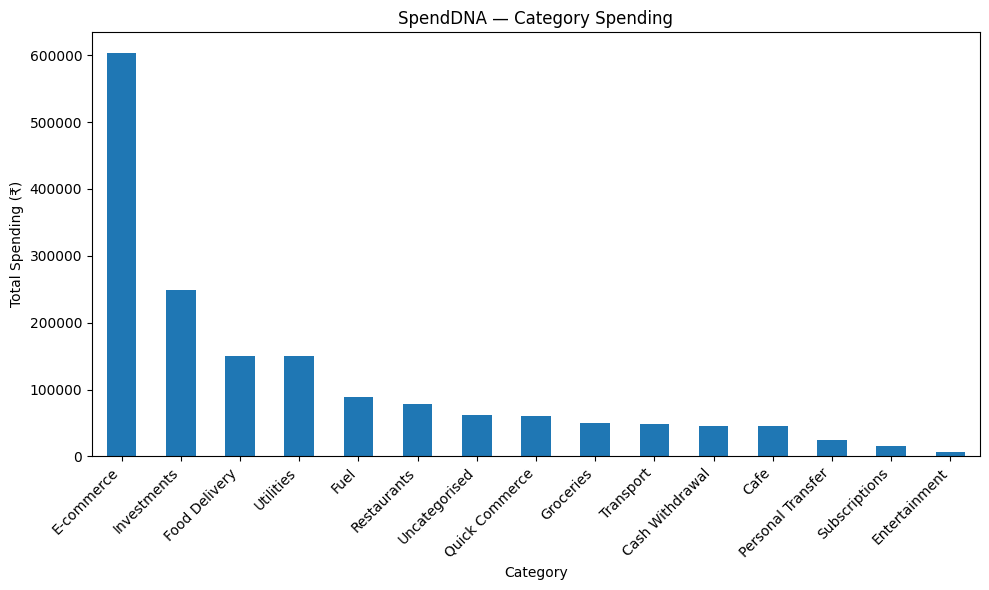

In [428]:
# ========== CATEGORY SPENDING CHART ==========

import matplotlib.pyplot as plt

category_spending = (
    debit_transactions
    .groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

category_spending.plot(kind="bar")

plt.title("SpendDNA — Category Spending")
plt.xlabel("Category")
plt.ylabel("Total Spending (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

/tmp/ipykernel_3433/1606675180.py:45: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


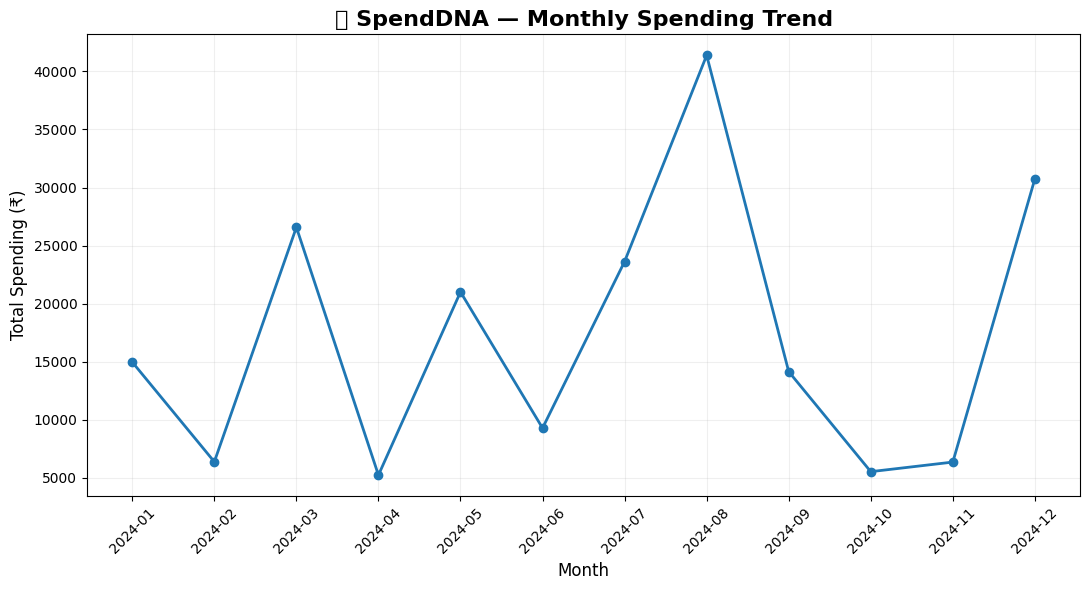

In [429]:
# ========== MONTHLY SPENDING TREND ==========

import matplotlib.pyplot as plt

# Make sure date is in datetime format
debit_transactions["date"] = pd.to_datetime(
    debit_transactions["date"],
    errors="coerce"
)

# Create monthly spending
monthly_spending = (
    debit_transactions
    .dropna(subset=["date"])
    .assign(month=lambda x: x["date"].dt.to_period("M"))
    .groupby("month")["amount"]
    .sum()
    .sort_index()
)

# Convert period to string for display
months = monthly_spending.index.astype(str)

plt.figure(figsize=(11, 6))

plt.plot(
    months,
    monthly_spending.values,
    marker="o",
    linewidth=2
)

plt.title(
    "🧬 SpendDNA — Monthly Spending Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Spending (₹)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3433/3538220005.py:31: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


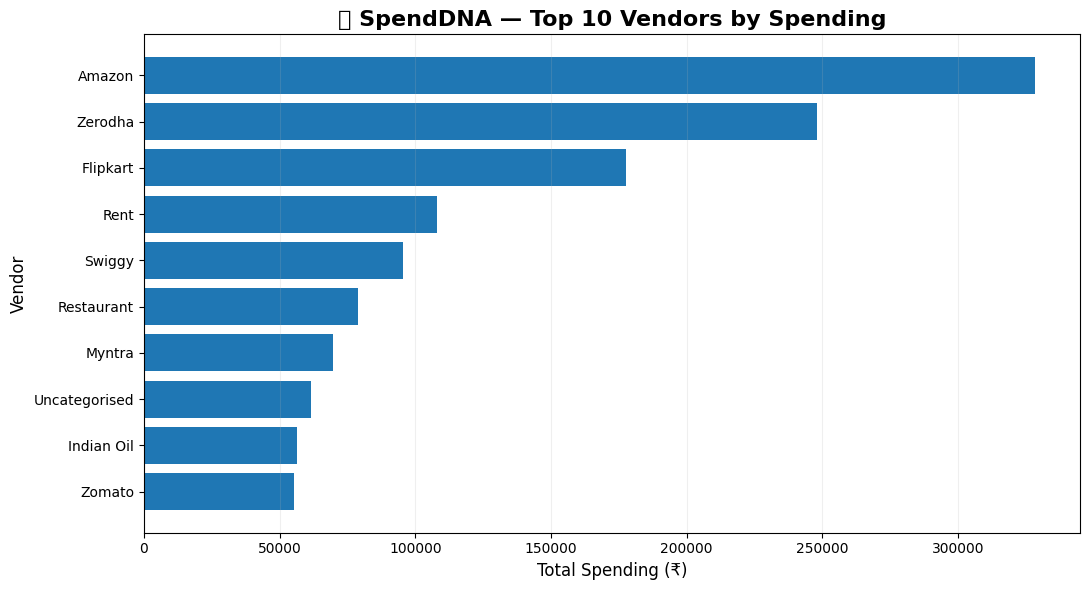

In [430]:
# ========== TOP VENDORS CHART ==========

import matplotlib.pyplot as plt

top_vendors = (
    debit_transactions
    .groupby("vendor_clean")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(11, 6))

plt.barh(
    top_vendors.index,
    top_vendors.values
)

plt.title(
    "🧬 SpendDNA — Top 10 Vendors by Spending",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Spending (₹)", fontsize=12)
plt.ylabel("Vendor", fontsize=12)

plt.grid(axis="x", alpha=0.2)
plt.tight_layout()

plt.show()

/tmp/ipykernel_3433/1721240431.py:56: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


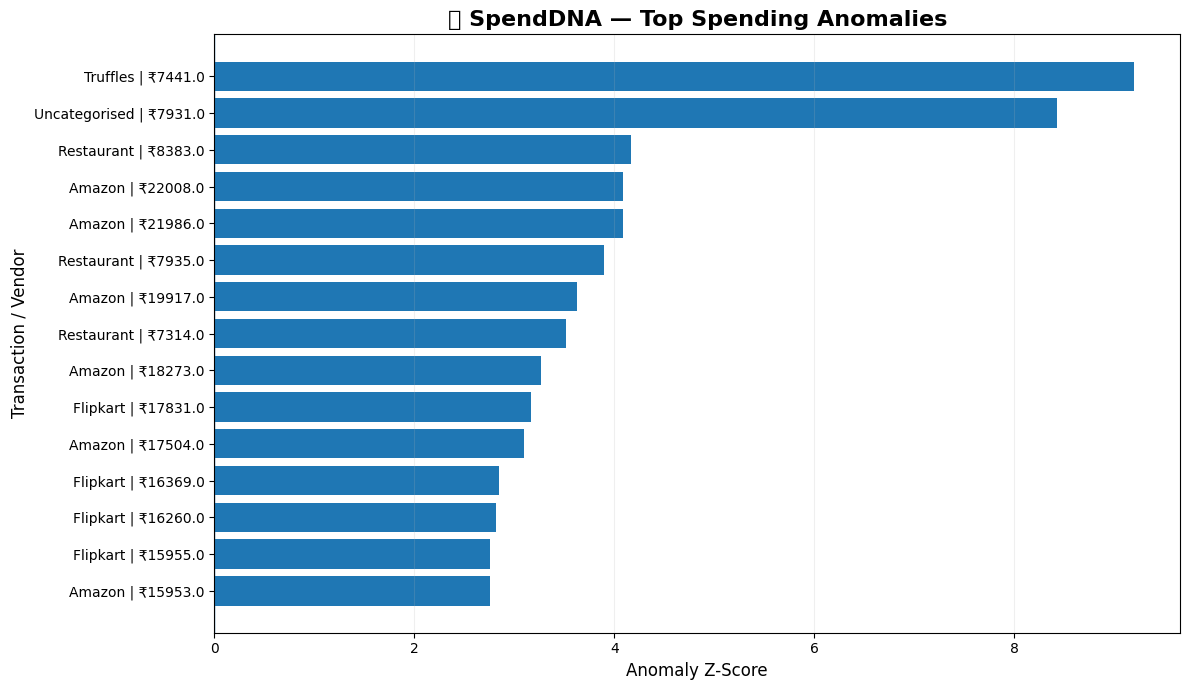

In [431]:
# ========== ANOMALY VISUALIZATION ==========

import matplotlib.pyplot as plt

if len(anomalies) > 0:

    # Copy anomalies safely
    anomaly_plot = anomalies.copy()

    # Ensure amount is numeric
    anomaly_plot["amount"] = pd.to_numeric(
        anomaly_plot["amount"],
        errors="coerce"
    )

    # Sort by anomaly severity
    anomaly_plot = (
        anomaly_plot
        .sort_values("z_score", ascending=False)
        .head(15)
    )

    # Create readable labels
    anomaly_plot["label"] = (
        anomaly_plot["vendor_clean"].astype(str)
        + " | ₹"
        + anomaly_plot["amount"].round(0).astype(str)
    )

    plt.figure(figsize=(12, 7))

    plt.barh(
        anomaly_plot["label"].iloc[::-1],
        anomaly_plot["z_score"].iloc[::-1]
    )

    plt.axvline(
        x=0,
        linewidth=1
    )

    plt.title(
        "🚨 SpendDNA — Top Spending Anomalies",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Anomaly Z-Score", fontsize=12)
    plt.ylabel("Transaction / Vendor", fontsize=12)

    plt.grid(
        axis="x",
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()

else:

    print("No significant anomalies detected.")

In [432]:
# ================================================================
# 🧬 SpendDNA — FINAL SPENDING INTELLIGENCE DASHBOARD
# ================================================================

import pandas as pd
import matplotlib.pyplot as plt

# -------------------- DATA PREPARATION --------------------

debit_transactions["date"] = pd.to_datetime(
    debit_transactions["date"],
    errors="coerce"
)

debit_transactions["amount"] = pd.to_numeric(
    debit_transactions["amount"],
    errors="coerce"
)

dashboard_data = debit_transactions.dropna(
    subset=["amount"]
).copy()

# -------------------- KPI CALCULATIONS --------------------

total_spending = dashboard_data["amount"].sum()

total_transactions = len(dashboard_data)

average_transaction = dashboard_data["amount"].mean()

# Category
category_spending = (
    dashboard_data
    .groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

top_category = category_spending.index[0]
top_category_amount = category_spending.iloc[0]

# Vendor
vendor_spending = (
    dashboard_data
    .groupby("vendor_clean")["amount"]
    .sum()
    .sort_values(ascending=False)
)

top_vendor = vendor_spending.index[0]
top_vendor_amount = vendor_spending.iloc[0]

# Monthly
dashboard_data["month"] = (
    dashboard_data["date"].dt.to_period("M")
)

monthly_spending = (
    dashboard_data
    .dropna(subset=["date"])
    .groupby("month")["amount"]
    .sum()
    .sort_index()
)

# Anomalies
if "anomalies" in globals() and len(anomalies) > 0:
    anomaly_count = len(anomalies)
else:
    anomaly_count = 0


# ================================================================
# DASHBOARD HEADER
# ================================================================

print("\n")
print("=" * 90)
print("                         🧬 SpendDNA")
print("                 PERSONAL SPENDING INTELLIGENCE")
print("=" * 90)


# ================================================================
# KPI SECTION
# ================================================================

print("\n💰 KEY FINANCIAL METRICS")
print("-" * 90)

print(f"Total Spending       : ₹{total_spending:,.2f}")
print(f"Transactions         : {total_transactions:,}")
print(f"Average Transaction  : ₹{average_transaction:,.2f}")
print(f"Top Category         : {top_category}")
print(f"Top Vendor           : {top_vendor}")
print(f"Anomalies Detected   : {anomaly_count}")


# ================================================================
# INSIGHTS
# ================================================================

print("\n🧠 SPENDING INTELLIGENCE")
print("-" * 90)

print(
    f"🏆 Highest spending category: "
    f"{top_category} → ₹{top_category_amount:,.2f}"
)

print(
    f"🏪 Highest spending vendor: "
    f"{top_vendor} → ₹{top_vendor_amount:,.2f}"
)

if anomaly_count > 0:
    print(
        f"🚨 {anomaly_count} unusual transaction(s) "
        f"were detected."
    )
else:
    print("✅ No significant spending anomalies detected.")


# ================================================================
# TOP 5 CATEGORIES
# ================================================================

print("\n📊 TOP 5 SPENDING CATEGORIES")
print("-" * 90)

for category, amount in category_spending.head(5).items():
    print(f"{category:<30} ₹{amount:,.2f}")


# ================================================================
# TOP 5 VENDORS
# ================================================================

print("\n🏪 TOP 5 VENDORS")
print("-" * 90)

for vendor, amount in vendor_spending.head(5).items():
    print(f"{vendor:<30} ₹{amount:,.2f}")


# ================================================================
# MONTHLY TREND
# ================================================================

print("\n📈 MONTHLY SPENDING TREND")
print("-" * 90)

for month, amount in monthly_spending.items():
    print(f"{str(month):<15} ₹{amount:,.2f}")


print("\n" + "=" * 90)
print("                    END OF SpendDNA DASHBOARD")
print("=" * 90)



                         🧬 SpendDNA
                 PERSONAL SPENDING INTELLIGENCE

💰 KEY FINANCIAL METRICS
------------------------------------------------------------------------------------------
Total Spending       : ₹1,678,901.00
Transactions         : 1,304
Average Transaction  : ₹1,287.50
Top Category         : E-commerce
Top Vendor           : Amazon
Anomalies Detected   : 35

🧠 SPENDING INTELLIGENCE
------------------------------------------------------------------------------------------
🏆 Highest spending category: E-commerce → ₹603,877.00
🏪 Highest spending vendor: Amazon → ₹328,530.00
🚨 35 unusual transaction(s) were detected.

📊 TOP 5 SPENDING CATEGORIES
------------------------------------------------------------------------------------------
E-commerce                     ₹603,877.00
Investments                    ₹248,160.00
Food Delivery                  ₹150,839.00
Utilities                      ₹149,914.00
Fuel                           ₹89,303.00

🏪 TOP 5 VENDO

In [433]:
# ================================================================
# 🧬 SpendDNA — FINAL VALIDATION CHECK
# ================================================================

print("=" * 80)
print("              🧬 SpendDNA — FINAL VALIDATION")
print("=" * 80)

print("\n✅ DATASET CHECK")
print("-" * 80)

print(f"Total records        : {len(debit_transactions):,}")
print(f"Total columns        : {len(debit_transactions.columns)}")
print(f"Missing values       : {debit_transactions.isna().sum().sum():,}")

print("\n✅ ANALYSIS CHECK")
print("-" * 80)

print(f"Categories analyzed  : {debit_transactions['category'].nunique()}")
print(f"Vendors analyzed     : {debit_transactions['vendor_clean'].nunique()}")

if "anomalies" in globals():
    print(f"Anomalies detected    : {len(anomalies):,}")
else:
    print("Anomalies detected    : Not calculated")

if "monthly_spending" in globals():
    print(f"Months analyzed       : {len(monthly_spending):,}")
else:
    print("Months analyzed       : Not calculated")

print("\n✅ REQUIRED COLUMNS")
print("-" * 80)

required_columns = [
    "date",
    "amount",
    "category",
    "vendor_clean"
]

for column in required_columns:
    if column in debit_transactions.columns:
        print(f"✓ {column}")
    else:
        print(f"✗ {column} — MISSING")

print("\n" + "=" * 80)
print("             🎉 SpendDNA VALIDATION COMPLETE")
print("=" * 80)

              🧬 SpendDNA — FINAL VALIDATION

✅ DATASET CHECK
--------------------------------------------------------------------------------
Total records        : 1,304
Total columns        : 21
Missing values       : 6,978

✅ ANALYSIS CHECK
--------------------------------------------------------------------------------
Categories analyzed  : 15
Vendors analyzed     : 37
Anomalies detected    : 35
Months analyzed       : 12

✅ REQUIRED COLUMNS
--------------------------------------------------------------------------------
✓ date
✓ amount
✓ category
✓ vendor_clean

             🎉 SpendDNA VALIDATION COMPLETE
